# Классификация текстов с помощью модели BERT



Рассмотрим задачу классификации текстов с использованием BERT.

Источник изложения: https://curiousily.com/posts/sentiment-analysis-with-bert-and-hugging-face-using-pytorch-and-python/

В качестве данных будем использовать отзывы на приложения в Google Play.
Данные будут содержать тексты отзывов и оценки, которые пользователи поставили приложениям (от 1 до 5).

Наша задача -- построить модель, которая сможет предсказать оценку пользователя на основе текста его отзыва.

Для решения этой задачи мы будем использовать модель BERT, основанную на архитектуре Transformer.

Мы научимся:
- Обрабатывать данные для модели BERT
- Дообучать модель BERT на нашем наборе данных
- Использовать обученную модель для оценки текстов

## Загрузка данных

Мы будем использовать библиотеку [Transformers](https://huggingface.co/transformers/) от Hugging Face

In [1]:
!pip install -q -U watermark

In [2]:
%reload_ext watermark
%watermark -v -p numpy,pandas,torch,transformers

Python implementation: CPython
Python version       : 3.11.14
IPython version      : 9.8.0

numpy       : 2.2.6
pandas      : 2.3.3
torch       : 2.5.1+cu121
transformers: 5.5.3



Загрузим набор данных, который мы будем использовать для обучения и тестирования модели -- отзывы на приложения в Google Play.


In [3]:
# !gdown --id 1S6qMioqPJjyBLpLVz4gmRTnJHnjitnuV
# !gdown --id 1zdmewp7ayS4js4VtrJEHzAheSW-5NBZv

In [4]:
import transformers
from transformers import BertModel, BertTokenizer
from torch.optim import AdamW  # или: from transformers.optimization import AdamW
from transformers import get_linear_schedule_with_warmup
import torch
import numpy as np
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from collections import defaultdict
from textwrap import wrap
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
%matplotlib inline
%config InlineBackend.figure_format='retina'
sns.set(style='whitegrid', palette='muted', font_scale=1.2)
HAPPY_COLORS_PALETTE = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]
sns.set_palette(sns.color_palette(HAPPY_COLORS_PALETTE))
rcParams['figure.figsize'] = 12, 8

In [5]:
df = pd.read_csv("reviews.csv")
print("Количество примеров: ", df.shape[0])
df.head()

Количество примеров:  15746


,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId
0,Andrew Thomas,https://lh3.googleusercontent.com/a-/AOh14GiHd...,Update: After getting a response from the deve...,1,21,4.17.0.3,2020-04-05 22:25:57,"According to our TOS, and the term you have ag...",2020-04-05 15:10:24,most_relevant,com.anydo
1,Craig Haines,https://lh3.googleusercontent.com/-hoe0kwSJgPQ...,Used it for a fair amount of time without any ...,1,11,4.17.0.3,2020-04-04 13:40:01,It sounds like you logged in with a different ...,2020-04-05 15:11:35,most_relevant,com.anydo
2,steven adkins,https://lh3.googleusercontent.com/a-/AOh14GiXw...,Your app sucks now!!!!! Used to be good but no...,1,17,4.17.0.3,2020-04-01 16:18:13,This sounds odd! We are not aware of any issue...,2020-04-02 16:05:56,most_relevant,com.anydo
3,Lars Panzerbjørn,https://lh3.googleusercontent.com/a-/AOh14Gg-h...,"It seems OK, but very basic. Recurring tasks n...",1,192,4.17.0.2,2020-03-12 08:17:34,We do offer this option as part of the Advance...,2020-03-15 06:20:13,most_relevant,com.anydo
4,Scott Prewitt,https://lh3.googleusercontent.com/-K-X1-YsVd6U...,Absolutely worthless. This app runs a prohibit...,1,42,4.17.0.2,2020-03-14 17:41:01,We're sorry you feel this way! 90% of the app ...,2020-03-15 23:45:51,most_relevant,com.anydo


In [6]:
df.shape

(15746, 11)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15746 entries, 0 to 15745
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   userName              15746 non-null  object
 1   userImage             15746 non-null  object
 2   content               15746 non-null  object
 3   score                 15746 non-null  int64 
 4   thumbsUpCount         15746 non-null  int64 
 5   reviewCreatedVersion  13533 non-null  object
 6   at                    15746 non-null  object
 7   replyContent          7367 non-null   object
 8   repliedAt             7367 non-null   object
 9   sortOrder             15746 non-null  object
 10  appId                 15746 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.3+ MB


Посмотрим на распределение классов в выборке

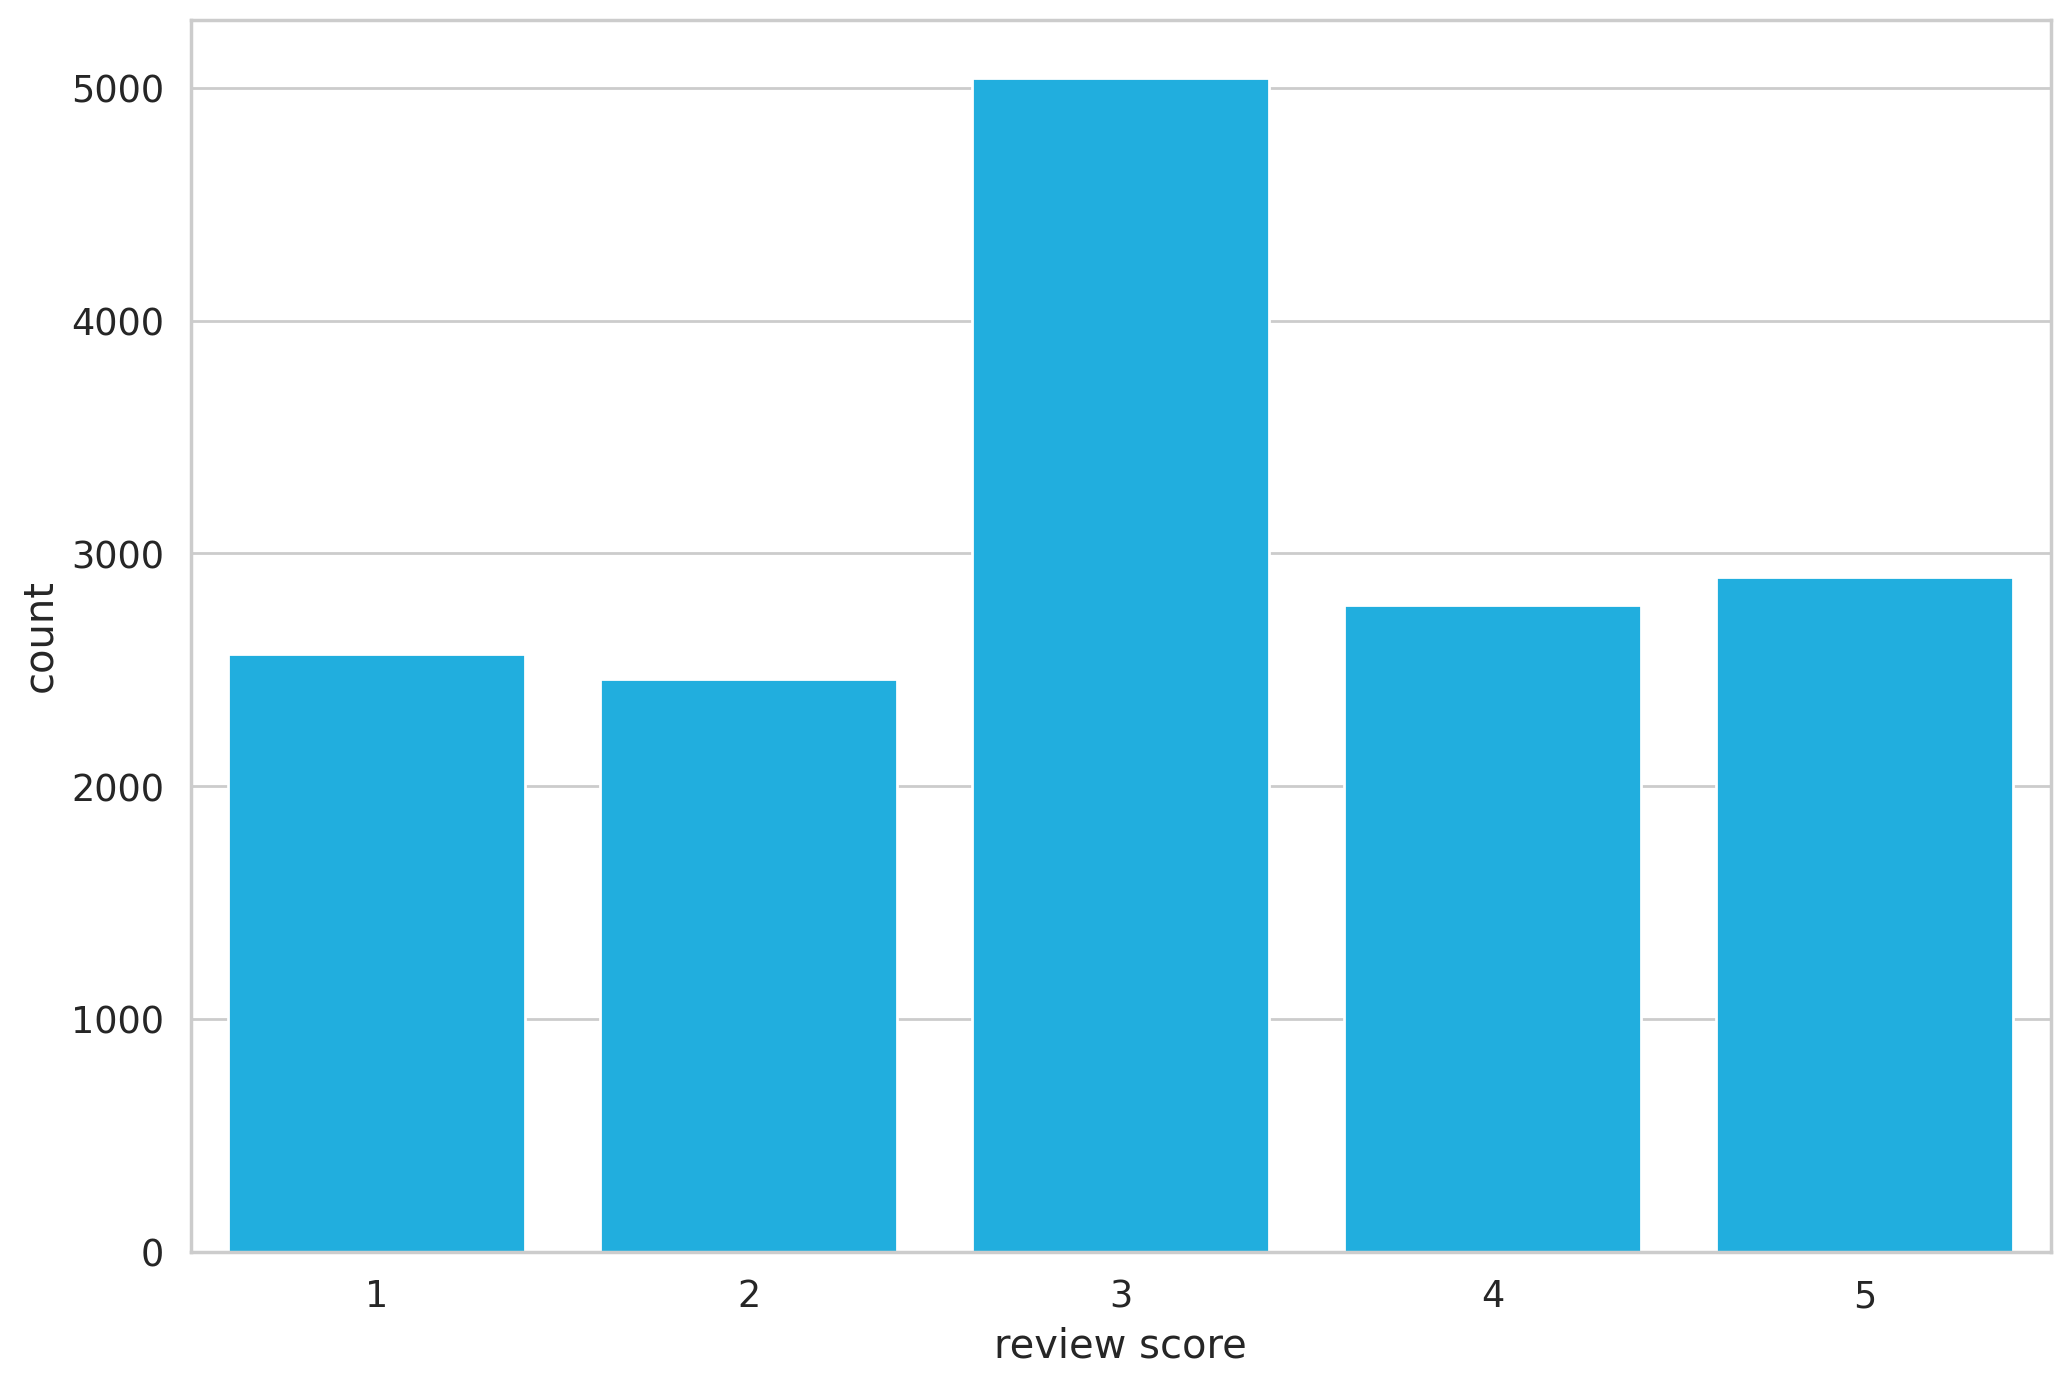

In [8]:
sns.countplot(x='score', data=df)
plt.xlabel('review score')
plt.show()

Можно видеть, что данные несбалансированы.
Теперь приведем метки классов к другому виду -- разделим их на 3 класса: негативные, нейтральные и позитивные.

In [9]:
def to_sentiment(rating):
  rating = int(rating)
  if rating <= 2:
    return 0
  elif rating == 3:
    return 1
  else:
    return 2

df['sentiment'] = df.score.apply(to_sentiment)

In [10]:
class_names = ['negative', 'neutral', 'positive']

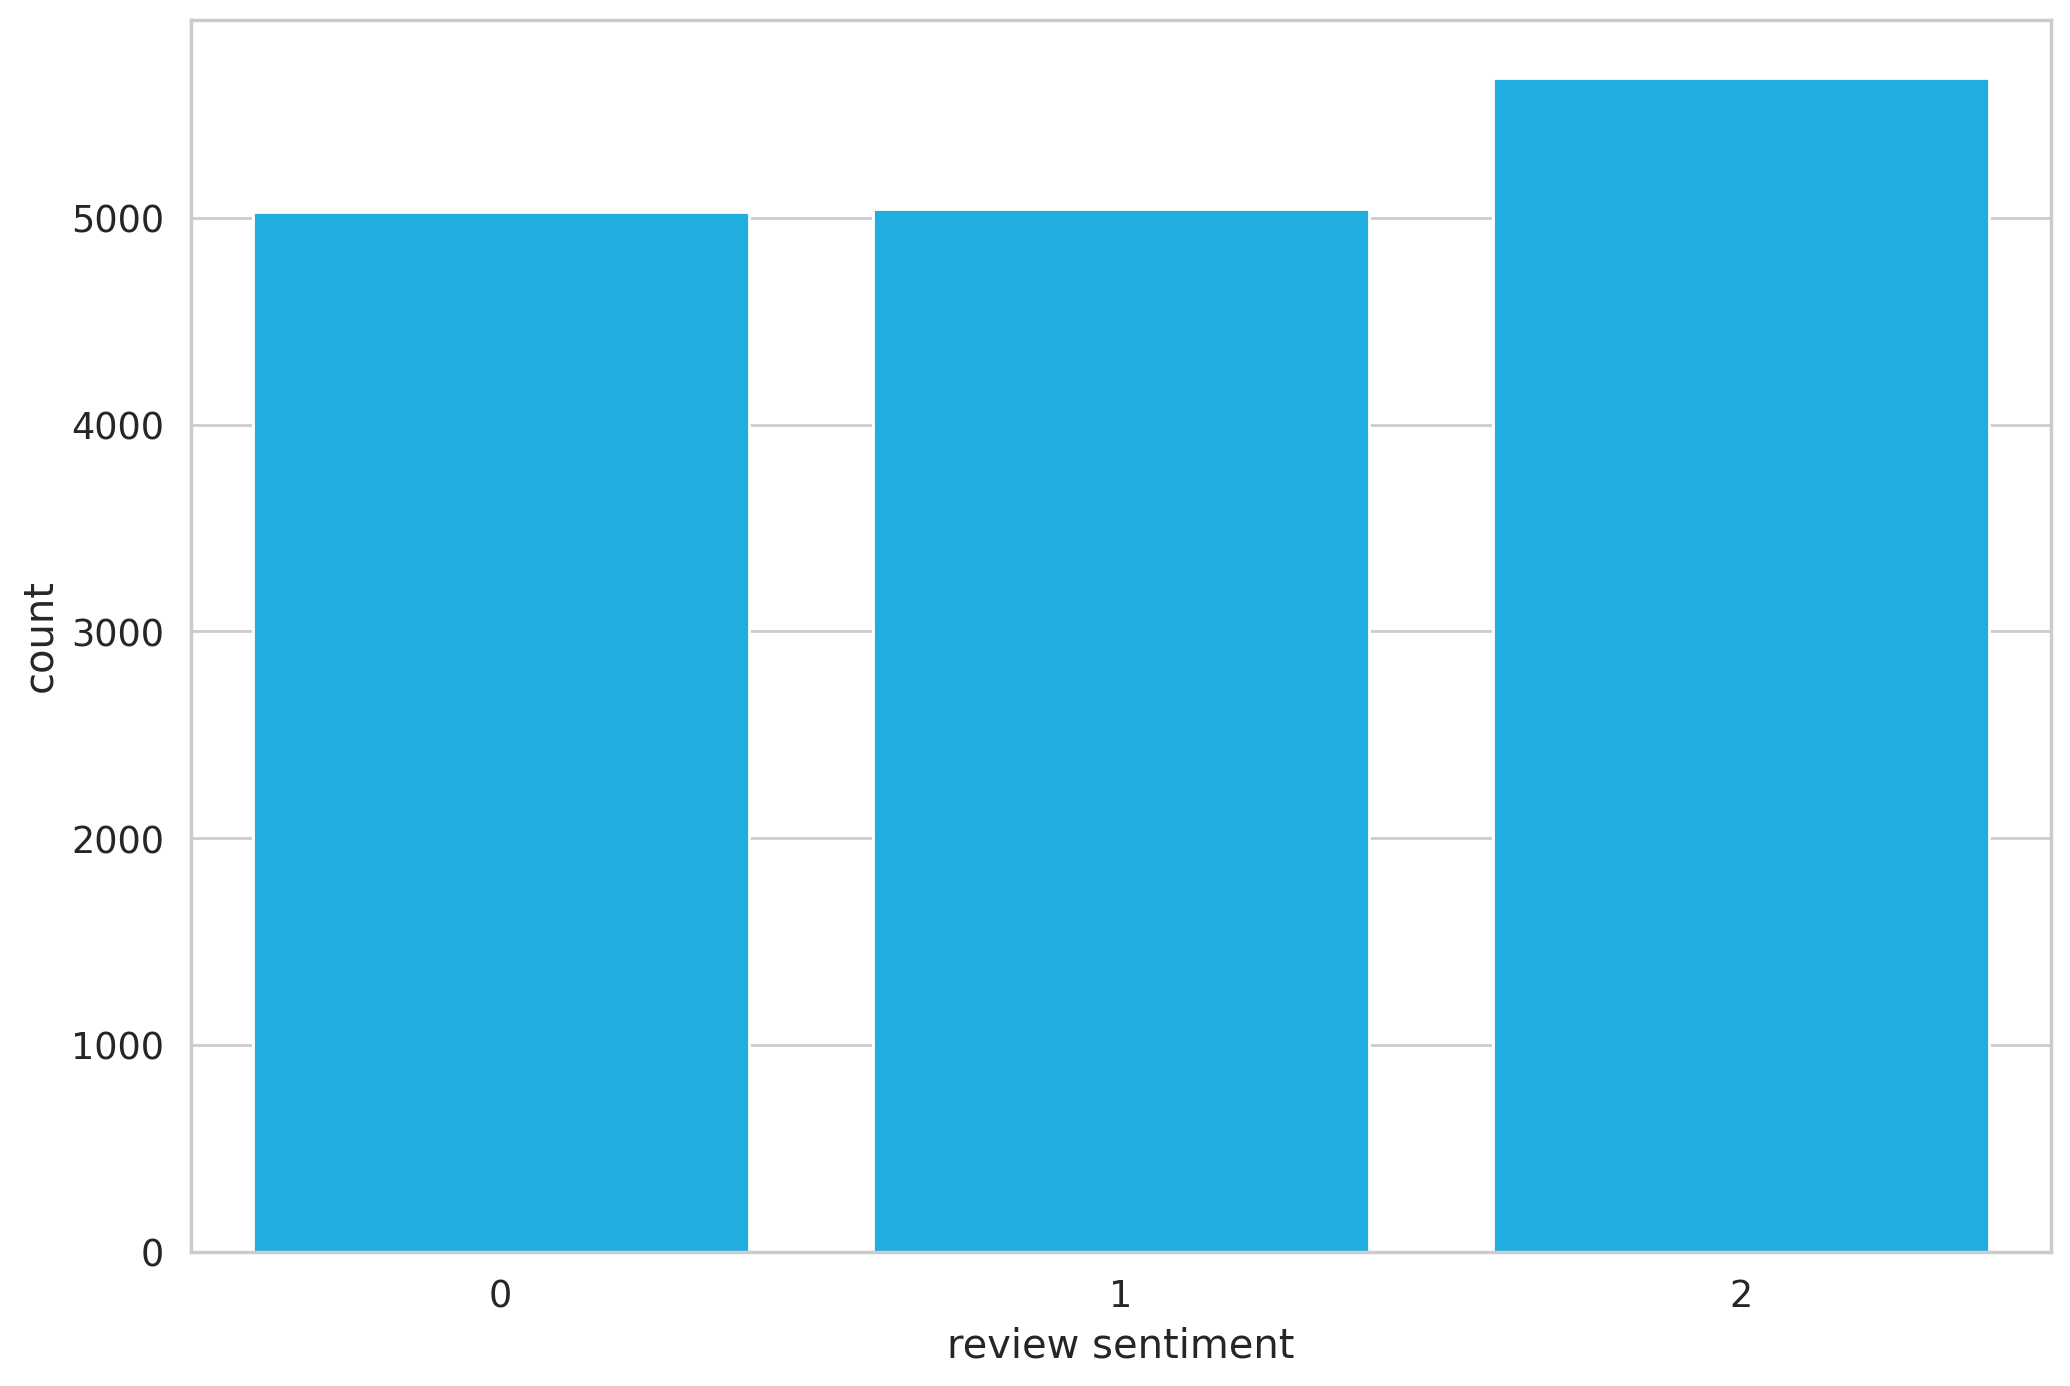

In [11]:
sns.countplot(x='sentiment', data=df)
plt.xlabel('review sentiment')
plt.show()

В таком виде классы почти сбалансированы.

## Предобработка данных

Для обучение модели BERT нам нужно обработать исходный текст определенным образом:
* Добавить служебные символы для разделения предложений и классификации
* Привести все последовательности к единой длине (используя padding)
* Создать список (*attention mask*) из 0 и 1, в котором 0 будут соответствовать вспомогательным токенам (padding), а 1 $-$ настоящим.

Будем использовать модели токенизации из библиотеки Hugging Face.

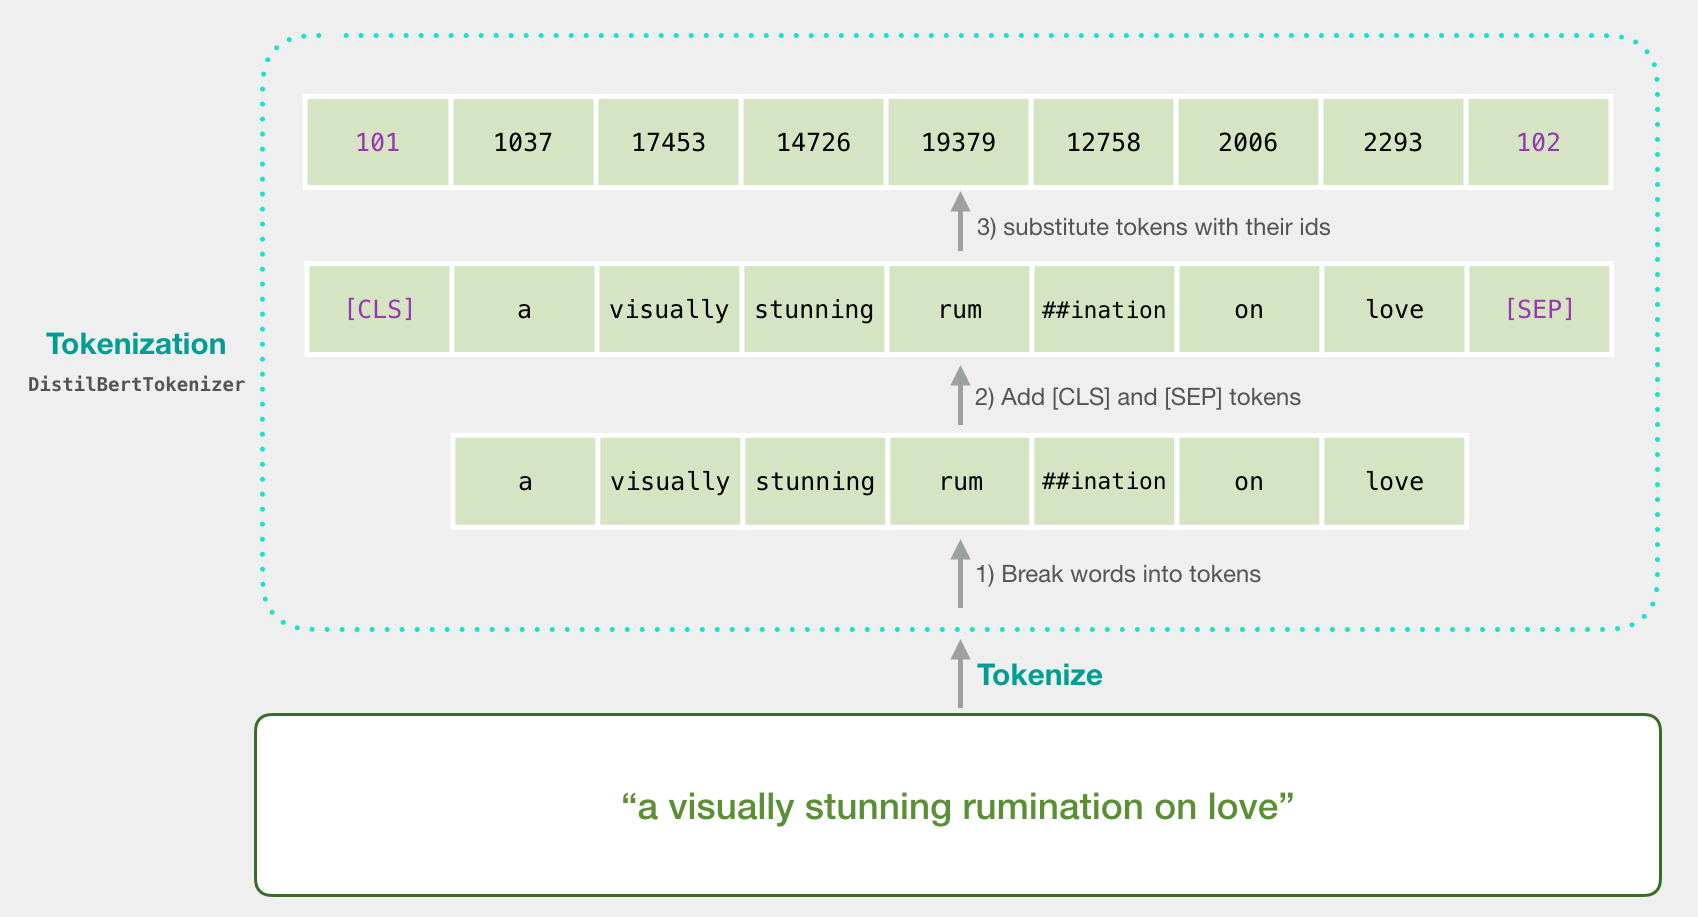

In [12]:
PRE_TRAINED_MODEL_NAME = "distilbert-base-uncased"

Загрузим предобученный [BertTokenizer](https://huggingface.co/transformers/model_doc/bert.html#berttokenizer):

In [13]:
tokenizer = BertTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME)

Посмотрим, как работает модель токенизации для BERT.



In [14]:
sample_txt = 'When was I last outside? I am stuck at home for 2 weeks.'

In [15]:
tokens = tokenizer.tokenize(sample_txt)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print(f' Sentence: {sample_txt}')
print(f'   Tokens: {tokens}')
print(f'Token IDs: {token_ids}')

 Sentence: When was I last outside? I am stuck at home for 2 weeks.
   Tokens: ['when', 'was', 'i', 'last', 'outside', '?', 'i', 'am', 'stuck', 'at', 'home', 'for', '2', 'weeks', '.']
Token IDs: [2043, 2001, 1045, 2197, 2648, 1029, 1045, 2572, 5881, 2012, 2188, 2005, 1016, 3134, 1012]


In [16]:
sample_txt = 'He started a new book, it was quite readable'

tokens = tokenizer.tokenize(sample_txt)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print(f' Sentence: {sample_txt}')
print(f'   Tokens: {tokens}')
print(f'Token IDs: {token_ids}')

 Sentence: He started a new book, it was quite readable
   Tokens: ['he', 'started', 'a', 'new', 'book', ',', 'it', 'was', 'quite', 'read', '##able']
Token IDs: [2002, 2318, 1037, 2047, 2338, 1010, 2009, 2001, 3243, 3191, 3085]



##  Специальные токены

`[SEP]` - метка конца предложения


In [17]:
tokenizer.sep_token, tokenizer.sep_token_id

('[SEP]', 102)

`[CLS]` - чтобы использовать модель BERT для классификации, мы должны добавить этот токен в начало каждого предложения

In [18]:
tokenizer.cls_token, tokenizer.cls_token_id

('[CLS]', 101)

Также существует специальный вспомогательный токен для выравнивания длин последовательностей

In [19]:
tokenizer.pad_token, tokenizer.pad_token_id

('[PAD]', 0)

Кроме того, существует специальный токен для неизвестных слов, которые не встречались в обучающей выборке

In [20]:
tokenizer.unk_token, tokenizer.unk_token_id

('[UNK]', 100)

In [21]:
encoding = tokenizer(
  sample_txt,
  max_length=32,
  add_special_tokens=True, # Добавить '[CLS]' и '[SEP]'
  return_token_type_ids=True,
  # Если вы используете BERT для задач, где несколько предложений (например, NLI или QA), включите return_token_type_ids=True.
  # Если работаете с одним предложением — этот параметр можно не указывать или оставить False.
  padding='max_length',
  # Длина последовательности (всегда будет равна max_length при padding='max_length')
  return_attention_mask=True,
  return_tensors='pt',  # Вернуть тензор PyTorch
)

encoding.keys()

KeysView({'input_ids': tensor([[ 101, 2002, 2318, 1037, 2047, 2338, 1010, 2009, 2001, 3243, 3191, 3085,
          102,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]])})

In [22]:
print(len(encoding['input_ids'][0]))
print(encoding['token_type_ids'][0])
encoding['input_ids'][0]

32
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])


tensor([ 101, 2002, 2318, 1037, 2047, 2338, 1010, 2009, 2001, 3243, 3191, 3085,
         102,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])

Такая же длина будет и у *attention mask*

In [23]:
print(len(encoding['attention_mask'][0]))
encoding['attention_mask']

32


tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]])

In [24]:
tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])


['[CLS]',
 'he',
 'started',
 'a',
 'new',
 'book',
 ',',
 'it',
 'was',
 'quite',
 'read',
 '##able',
 '[SEP]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]']

Установим максимальную длину последовательности равной 160

In [25]:
MAX_LEN = 100

Теперь создадим датасет PyTorch, который понадобится в дальнейшем для обучения модели

In [26]:
class GPReviewDataset(Dataset):

  def __init__(self, reviews, targets, tokenizer, max_len):
    self.reviews = reviews
    self.targets = targets
    self.tokenizer = tokenizer
    self.max_len = max_len

  def __len__(self):
    return len(self.reviews)

  def __getitem__(self, item):
    review = str(self.reviews[item])
    target = self.targets[item]

    encoding = self.tokenizer(
            review,
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_token_type_ids=False,
            return_attention_mask=True,
            return_tensors="pt",
        )

    return {
      'review_text': review,
      "input_ids": encoding["input_ids"].squeeze(0),
      'attention_mask': encoding['attention_mask'].flatten(),
      'targets': torch.tensor(target, dtype=torch.long)
    }

Разделим данные на обучающую, тестовую и валидационную выборки

In [27]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [28]:
df_train, df_test = train_test_split(df, test_size=0.1, random_state=RANDOM_SEED)
df_val, df_test = train_test_split(df_test, test_size=0.5, random_state=RANDOM_SEED)

In [29]:
df_train.shape, df_val.shape, df_test.shape

((14171, 12), (787, 12), (788, 12))

In [30]:
df_train = df_train[:1000]

In [31]:
df_train.shape

(1000, 12)

In [32]:
df_val = df_val[:100]

In [33]:
df_test = df_test[:100]

Для обработки данных нам также нужно будет создать итераторы
- train_data_loader - данные для обучения
- val_data_loader - данные для валидации модели при обучении
- test_data_loader - данные для тестирования модели

In [34]:
import warnings
warnings.filterwarnings('ignore')

In [35]:
def create_data_loader(df, tokenizer, max_len, batch_size):
  ds = GPReviewDataset(
    reviews=df.content.to_numpy(),
    targets=df.sentiment.to_numpy(),
    tokenizer=tokenizer,
    max_len=max_len
  )

  return DataLoader(
    ds,
    batch_size=batch_size,
    num_workers=4
  )

In [36]:
BATCH_SIZE = 4

train_data_loader = create_data_loader(df_train, tokenizer, MAX_LEN, BATCH_SIZE)
val_data_loader = create_data_loader(df_val, tokenizer, MAX_LEN, BATCH_SIZE)
test_data_loader = create_data_loader(df_test, tokenizer, MAX_LEN, BATCH_SIZE)

Посмотрим на пример одного батча из нашего итератора train_data_loader



In [37]:
data = next(iter(train_data_loader))

In [38]:
data.keys()

dict_keys(['review_text', 'input_ids', 'attention_mask', 'targets'])

In [39]:
print(data['input_ids'].shape)
print(data['attention_mask'].shape)
print(data['targets'].shape)

torch.Size([4, 100])
torch.Size([4, 100])
torch.Size([4])


## Классификация сентимента с использованием модели BERT от Hugging Face


В библиотеке Transformers от Hugging Face есть много моделей для разных задач: [BertForSequenceClassification](https://huggingface.co/transformers/model_doc/bert.html#bertforsequenceclassification), [BertForQuestionAnswering](https://huggingface.co/transformers/model_doc/bert.html#bertforquestionanswering) и другие. Все они являются надстройками над базовой моделью BERT.

В данном случае мы будем использовать базовую модель [BertModel](https://huggingface.co/transformers/model_doc/bert.html#bertmodel) и реализуем на её основе свой классификатор текстов по тональности.

In [40]:
bert_model = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME)

You are using a model of type `distilbert` to instantiate a model of type `bert`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights: 0it [00:00, ?it/s]

BertModel LOAD REPORT from: distilbert-base-uncased
Key                                                                      | Status     | 
-------------------------------------------------------------------------+------------+-
vocab_transform.weight                                                   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.k_lin.weight   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.bias     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.k_lin.bias     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.bias     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.output_layer_norm.bias   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.output_layer_norm.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin2.bias            | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.sa_layer_n

Попробуем использовать эту модель

In [41]:
outputs = bert_model(
  input_ids=encoding['input_ids'],
  attention_mask=encoding['attention_mask']
)

Модель возвращает вектора для каждого токена в документе и вектор для токена [CLS], в котором хранится векторное представление всего документа

In [42]:
outputs.keys()

odict_keys(['last_hidden_state', 'pooler_output'])

In [43]:
last_hidden_state = outputs['last_hidden_state']


В переменную last_hidden_state теперь записана последовательность скрытых состояний последнего слоя модели.

In [44]:
last_hidden_state.shape

torch.Size([1, 32, 768])

Посмотрим на BERT эмбеддинги некоторых слов в предложениях.

In [45]:
df.loc[16]['content']

"Couldn't even set up one single recurring reminder without being required to pay monthly subscription. Get your greedy hand off it dev. It's only only a reminder app not a useful service."

In [46]:
sample_txt = df.loc[16]['content']

In [47]:
encoding = tokenizer(
  sample_txt,
  max_length=32,
  add_special_tokens=True, # Добавить '[CLS]' и '[SEP]'
  return_token_type_ids=False,
  padding="max_length",
  return_attention_mask=True,
  return_tensors='pt',  # Вернуть тензор PyTorch
)

In [48]:
last_hidden_state = bert_model(
  input_ids=encoding['input_ids'],
  attention_mask=encoding['attention_mask']
)['last_hidden_state']

In [49]:
last_hidden_state.shape

torch.Size([1, 41, 768])

In [50]:
print(tokenizer.convert_ids_to_tokens(encoding['input_ids'][0]))

['[CLS]', 'couldn', "'", 't', 'even', 'set', 'up', 'one', 'single', 'recurring', 'reminder', 'without', 'being', 'required', 'to', 'pay', 'monthly', 'subscription', '.', 'get', 'your', 'greedy', 'hand', 'off', 'it', 'dev', '.', 'it', "'", 's', 'only', 'only', 'a', 'reminder', 'app', 'not', 'a', 'useful', 'service', '.', '[SEP]']


In [51]:
tokenizer.convert_ids_to_tokens(encoding['input_ids'][0]).index('subscription')

17

In [52]:
last_hidden_state

tensor([[[-0.3214, -1.9521, -0.0615,  ...,  0.2284, -0.3407, -1.8877],
         [ 0.1519, -1.6542,  0.4859,  ...,  0.3463,  0.6572, -1.2551],
         [-1.2218,  0.0567,  2.3716,  ..., -0.2240,  0.0594, -0.3030],
         ...,
         [ 0.1742, -0.5297, -0.7519,  ...,  0.2742,  0.9040, -1.3484],
         [ 0.1170,  0.2630,  0.2828,  ...,  0.4244,  0.0655, -0.3745],
         [-0.2027, -0.7513,  0.7115,  ...,  1.5249,  0.2764, -0.5145]]],
       grad_fn=<NativeLayerNormBackward0>)

In [53]:
emb0 = last_hidden_state[0, 17]
emb0.shape

torch.Size([768])

In [54]:
df.loc[338]['content']

'Well designed and all however alot of the crutial features are locked behind the premium which u need to pay for'

In [55]:
sample_txt = df.loc[338]['content']
encoding = tokenizer(
  sample_txt,
  max_length=32,
  add_special_tokens=True, # Добавить '[CLS]' и '[SEP]'
  return_token_type_ids=False,
  padding="max_length",
  return_attention_mask=True,
  return_tensors='pt',  # Вернуть тензор PyTorch
)
last_hidden_state = bert_model(
  input_ids=encoding['input_ids'],
  attention_mask=encoding['attention_mask']
)['last_hidden_state']

In [56]:
tokenizer.convert_ids_to_tokens(encoding['input_ids'][0]).index('premium')

18

In [57]:
emb1 = last_hidden_state[0, 18]
emb1.shape

torch.Size([768])

In [58]:
emb1

tensor([ 7.2796e-01, -2.1196e+00,  4.5500e-01, -1.4683e+00,  1.0205e+00,
         6.5586e-01,  4.3093e-01, -1.2450e+00,  1.3440e+00,  4.4953e-01,
         1.1269e+00,  1.3940e+00, -4.2717e-01, -3.0370e-01, -2.1025e-01,
        -7.4331e-02,  7.4820e-01, -2.6610e-01, -1.0008e+00, -1.0959e+00,
         1.3737e+00, -4.6687e-01,  8.6152e-01,  1.2127e+00,  1.0997e-01,
         1.4507e+00,  2.3032e-01,  2.5444e-01, -5.3634e-01,  5.6122e-01,
         2.1356e-01, -2.3233e-01,  2.8137e-01,  3.8464e-01,  2.2163e-01,
         2.5170e+00,  8.6730e-01,  7.2537e-01,  6.6525e-01,  1.5493e+00,
        -1.6661e+00, -3.2198e-01,  2.7918e+00, -1.9132e-01, -1.8527e-01,
         3.9511e-01, -1.4275e+00, -3.1461e-01, -1.2052e-01, -3.5614e-02,
        -8.7357e-01, -2.1357e+00, -3.5857e-01, -1.5064e+00,  1.1837e-01,
         6.0543e-01,  3.2582e-01, -1.0582e-01,  1.0791e+00, -1.6575e+00,
        -1.8386e+00,  5.9215e-01, -6.1158e-01, -2.4286e-01, -5.7688e-01,
        -9.1736e-01, -4.2293e-01,  1.1950e+00, -1.1

In [59]:
from sklearn.metrics.pairwise import cosine_similarity

In [60]:
cosine_similarity([
    emb0.detach().cpu().numpy(),
    emb1.detach().cpu().numpy()])

array([[1.       , 0.6243425],
       [0.6243425, 1.0000001]], dtype=float32)

#### Классификатор

Будем использовать модель BERT с линейным слоем для классификации.

In [61]:
class SentimentClassifier(nn.Module):

  def __init__(self, n_classes):
    super(SentimentClassifier, self).__init__()
    self.bert = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME)
    self.drop = nn.Dropout(p=0.3)
    self.out = nn.Linear(self.bert.config.hidden_size, n_classes)

  def forward(self, input_ids, attention_mask):
    outputs = self.bert(
      input_ids=input_ids,
      attention_mask=attention_mask
    )
    output = self.drop(outputs["pooler_output"])
    return self.out(output)

In [62]:
model = SentimentClassifier(len(class_names))
model = model.to(device)

You are using a model of type `distilbert` to instantiate a model of type `bert`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights: 0it [00:00, ?it/s]

BertModel LOAD REPORT from: distilbert-base-uncased
Key                                                                      | Status     | 
-------------------------------------------------------------------------+------------+-
vocab_transform.weight                                                   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.k_lin.weight   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.bias     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.k_lin.bias     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.bias     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.output_layer_norm.bias   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.output_layer_norm.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin2.bias            | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.sa_layer_n

In [63]:
model

SentimentClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwi

Перенесем на GPU один из наших батчей (для примера).

In [64]:
input_ids = data['input_ids'].to(device)
attention_mask = data['attention_mask'].to(device)

print(input_ids.shape) # batch size x seq length
print(attention_mask.shape) # batch size x seq length

torch.Size([4, 100])
torch.Size([4, 100])


Чтобы получить вероятности классов, мы применим SoftMax к выходу модели.

In [65]:
import torch.nn.functional as F

In [66]:
F.softmax(model(input_ids, attention_mask), dim=1)

tensor([[0.3777, 0.2380, 0.3843],
        [0.3016, 0.3108, 0.3875],
        [0.3664, 0.2255, 0.4081],
        [0.3916, 0.2375, 0.3709]], device='cuda:0', grad_fn=<SoftmaxBackward0>)

## Обучение модели

Для дообучения модели будем использовать оптимайзер [AdamW](https://huggingface.co/transformers/main_classes/optimizer_schedules.html#adamw) из библиотеки Hugging Face.



Авторы модели BERT рекомендуют использовать следующие параметры для дообучения модели:
- Размер батча: 16, 32
- Learning rate (с оптимайзером Adam): 5e-5, 3e-5, 2e-5
- Количество эпох: 2, 3, 4

In [67]:
EPOCHS = 5 #10

optimizer = AdamW(model.parameters(), lr=2e-5)
total_steps = len(train_data_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
  optimizer,
  num_warmup_steps=0,
  num_training_steps=total_steps
)

loss_fn = nn.CrossEntropyLoss().to(device)

Реализуем функцию для одной эпохи обучения

In [68]:
def train_epoch(
  model,
  data_loader,
  loss_fn,
  optimizer,
  device,
  scheduler,
  n_examples
):
  model = model.train()

  losses = []
  correct_predictions = 0

  for d in data_loader:
    input_ids = d["input_ids"].to(device)
    attention_mask = d["attention_mask"].to(device)
    targets = d["targets"].to(device)

    outputs = model(
      input_ids=input_ids,
      attention_mask=attention_mask
    )

    _, preds = torch.max(outputs, dim=1)
    loss = loss_fn(outputs, targets)

    correct_predictions += torch.sum(preds == targets)
    losses.append(loss.item())

    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    optimizer.zero_grad()

  return correct_predictions.double() / n_examples, np.mean(losses)

Также реализуем функцию для оценки качества модели на данных из data_loader

In [69]:
def eval_model(model, data_loader, loss_fn, device, n_examples):
  model = model.eval()

  losses = []
  correct_predictions = 0

  with torch.no_grad():
    for d in data_loader:
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      targets = d["targets"].to(device)

      outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
      )
      _, preds = torch.max(outputs, dim=1)

      loss = loss_fn(outputs, targets)

      correct_predictions += torch.sum(preds == targets)
      losses.append(loss.item())

  return correct_predictions.double() / n_examples, np.mean(losses)

Используя эти две функции, описанные выше, реализуем процедуру дообучения нашей модели

In [70]:
import torch
torch.cuda.empty_cache()

In [71]:
%%time

history = defaultdict(list)
best_accuracy = 0

for epoch in range(EPOCHS):

  print(f'Epoch {epoch + 1}/{EPOCHS}')
  print('-' * 10)

  train_acc, train_loss = train_epoch(
    model,
    train_data_loader,
    loss_fn,
    optimizer,
    device,
    scheduler,
    len(df_train)
  )

  print(f'Train loss {train_loss} accuracy {train_acc}')

  val_acc, val_loss = eval_model(
    model,
    val_data_loader,
    loss_fn,
    device,
    len(df_val)
  )

  print(f'Val   loss {val_loss} accuracy {val_acc}')
  print()

  history['train_acc'].append(train_acc)
  history['train_loss'].append(train_loss)
  history['val_acc'].append(val_acc)
  history['val_loss'].append(val_loss)

  if val_acc > best_accuracy:
    torch.save(model.state_dict(), 'best_model_state.bin')
    best_accuracy = val_acc

Epoch 1/5
----------
Train loss 1.141596909046173 accuracy 0.364
Val   loss 1.2173814821243285 accuracy 0.31

Epoch 2/5
----------
Train loss 1.1302553353309632 accuracy 0.356
Val   loss 1.1339124536514282 accuracy 0.31

Epoch 3/5
----------
Train loss 1.0780806390047073 accuracy 0.41100000000000003
Val   loss 1.00082377910614 accuracy 0.5

Epoch 4/5
----------
Train loss 0.9204452491998673 accuracy 0.542
Val   loss 1.0051385354995728 accuracy 0.51

Epoch 5/5
----------
Train loss 0.8014195400476456 accuracy 0.623
Val   loss 1.0009292817115785 accuracy 0.53

CPU times: user 3min 36s, sys: 3.62 s, total: 3min 39s
Wall time: 3min 48s



При обучении модели мы сохраняем веса наилучшей модели на основе точности на валидационной выборке.

Обучение модели занимает некоторое время. Теперь мы можем сравнить точность на валидационной и на обучающей выборке.

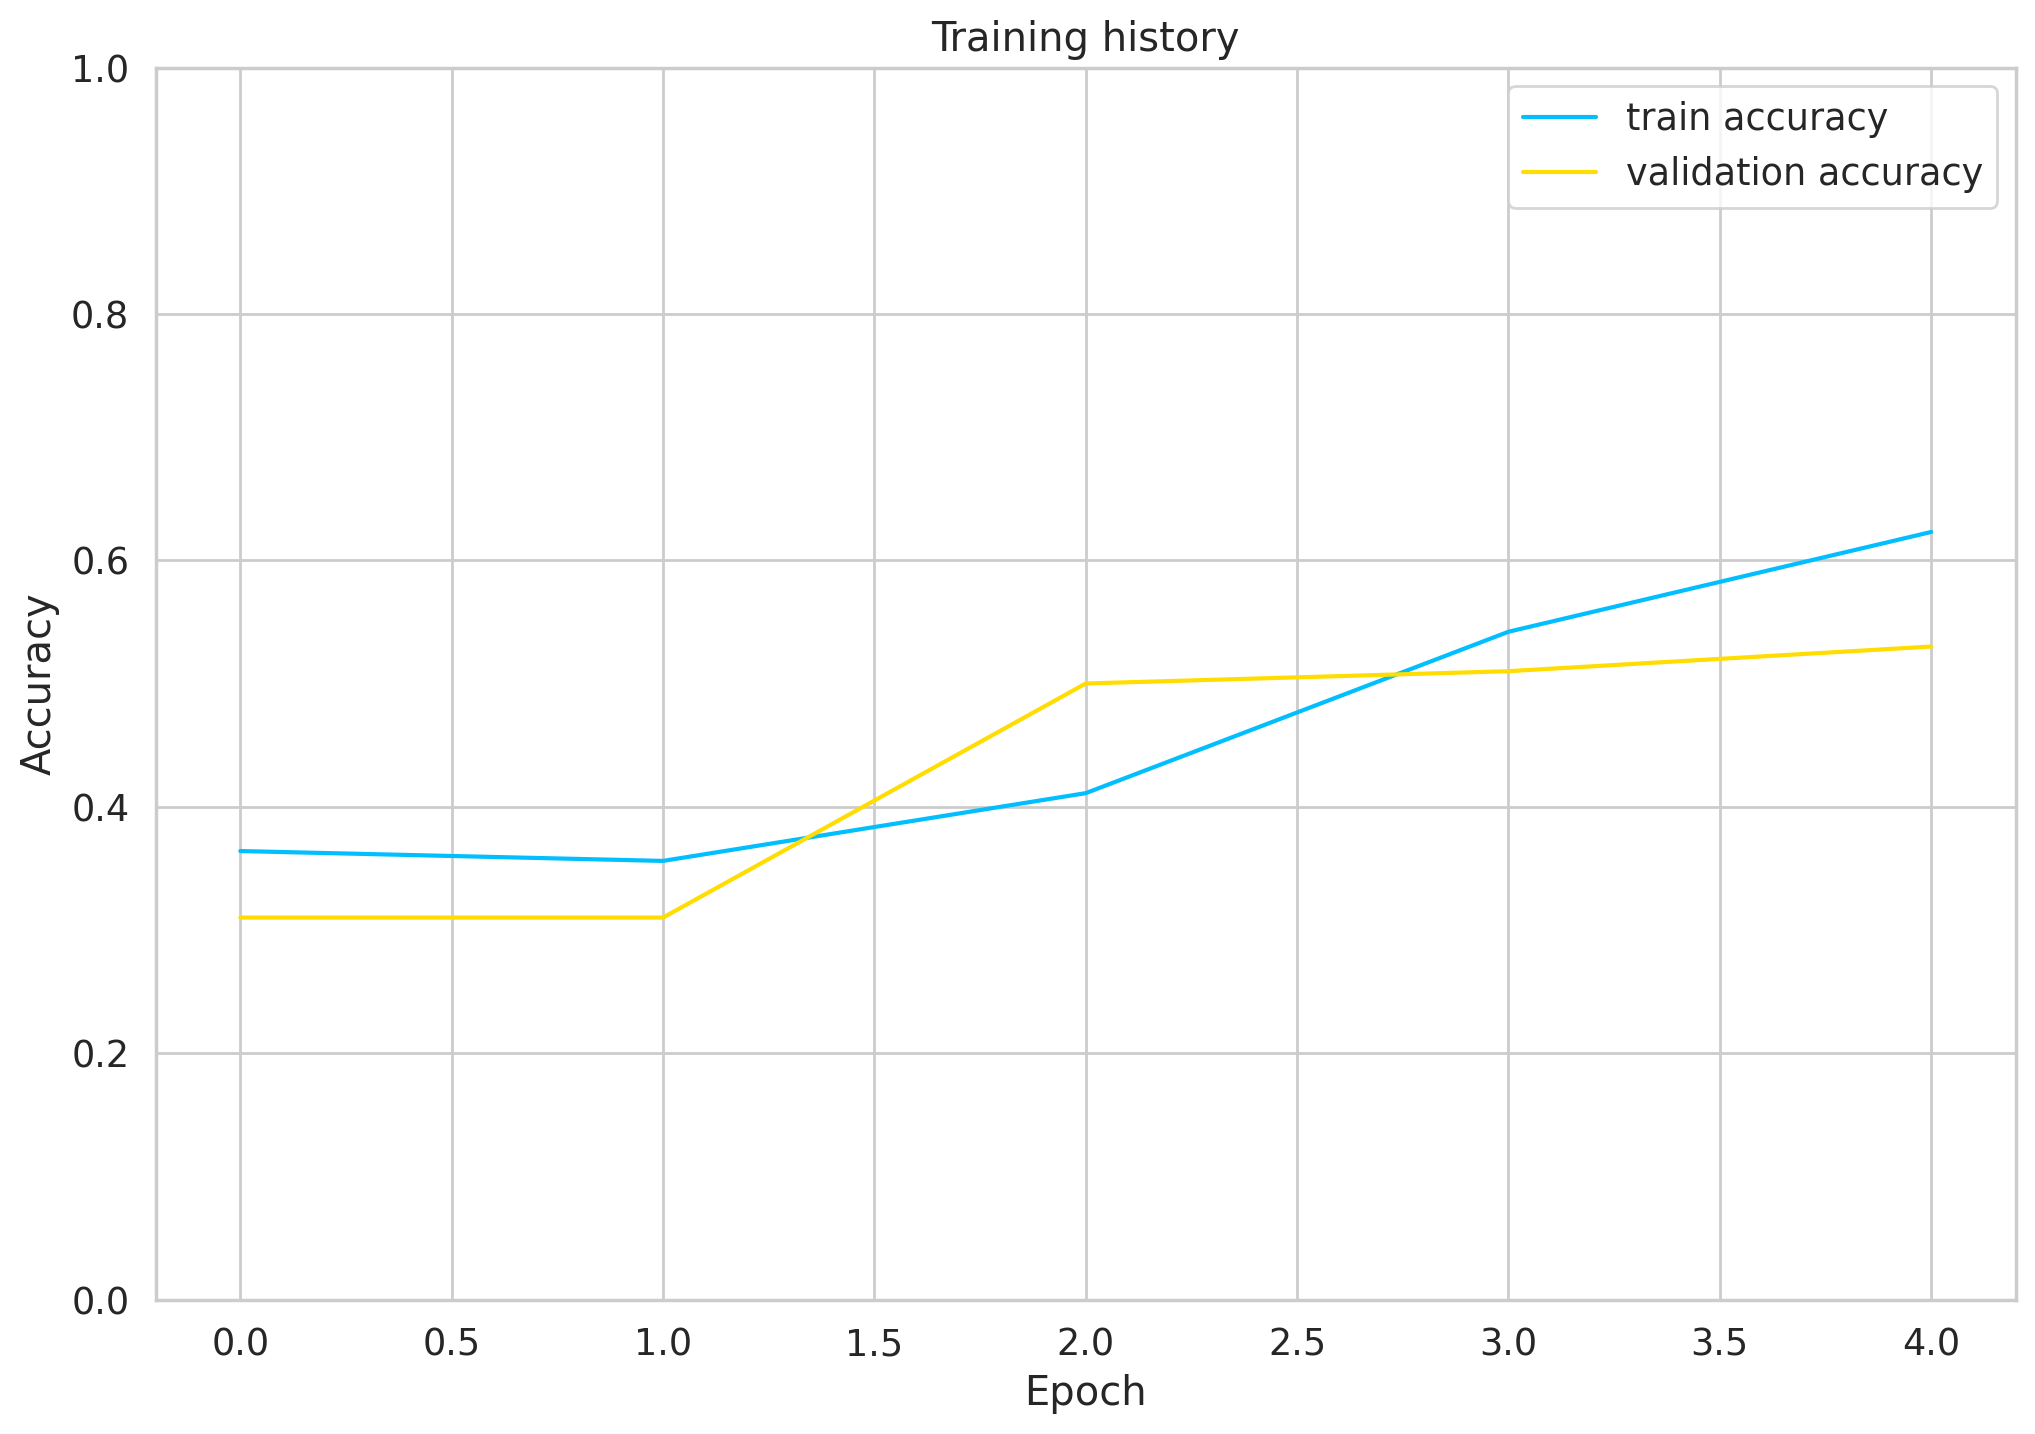

In [73]:
train_acc = [x.cpu().item() for x in history['train_acc']]
val_acc = [x.cpu().item() for x in history['val_acc']]

plt.plot(train_acc, label='train accuracy')
plt.plot(val_acc, label='validation accuracy')

plt.title('Training history')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.ylim([0, 1]);

Из графика видно, что доля правильных ответов модели при обучении приближается к 100% после приблизительно 10 эпох.

In [ ]:
# model = SentimentClassifier(len(class_names))
# model.load_state_dict(torch.load('best_model_state.bin'))
# model = model.to(device)

## Оценка результатов работы модели

Подсчитаем точность (accuracy) модели на тестовой выборке.

In [74]:
test_acc, _ = eval_model(
  model,
  test_data_loader,
  loss_fn,
  device,
  len(df_test)
)

test_acc.item()

0.59

Accuracy на тестовых данных и на валидационной выборке дают близкие значения. Из этого можно сделать вывод, что получившаяся модель обладает хорошей обобщающей способностью.

Теперь реализуем вспомогательную функцию, которая будет получать предсказания из нашей модели.

In [75]:
def get_predictions(model, data_loader):
  model = model.eval()

  review_texts = []
  predictions = []
  prediction_probs = []
  real_values = []

  with torch.no_grad():
    for d in data_loader:

      texts = d["review_text"]
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      targets = d["targets"].to(device)

      outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
      )
      _, preds = torch.max(outputs, dim=1)

      probs = F.softmax(outputs, dim=1)

      review_texts.extend(texts)
      predictions.extend(preds)
      prediction_probs.extend(probs)
      real_values.extend(targets)

  predictions = torch.stack(predictions).cpu()
  prediction_probs = torch.stack(prediction_probs).cpu()
  real_values = torch.stack(real_values).cpu()
  return review_texts, predictions, prediction_probs, real_values

In [76]:
y_review_texts, y_pred, y_pred_probs, y_test = get_predictions(
  model,
  test_data_loader
)

Давайте посмотрим на результаты работы модели на тестовой выборке.

In [77]:
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    negative       0.47      0.65      0.55        26
     neutral       0.52      0.39      0.44        36
    positive       0.76      0.74      0.75        38

    accuracy                           0.59       100
   macro avg       0.58      0.59      0.58       100
weighted avg       0.60      0.59      0.59       100



Из данного отчета видно, что сложнее всего классифицировать нейтральные отзывы.

Посмотрим также на confusion matrix предсказаний модели на тестовой выборке.

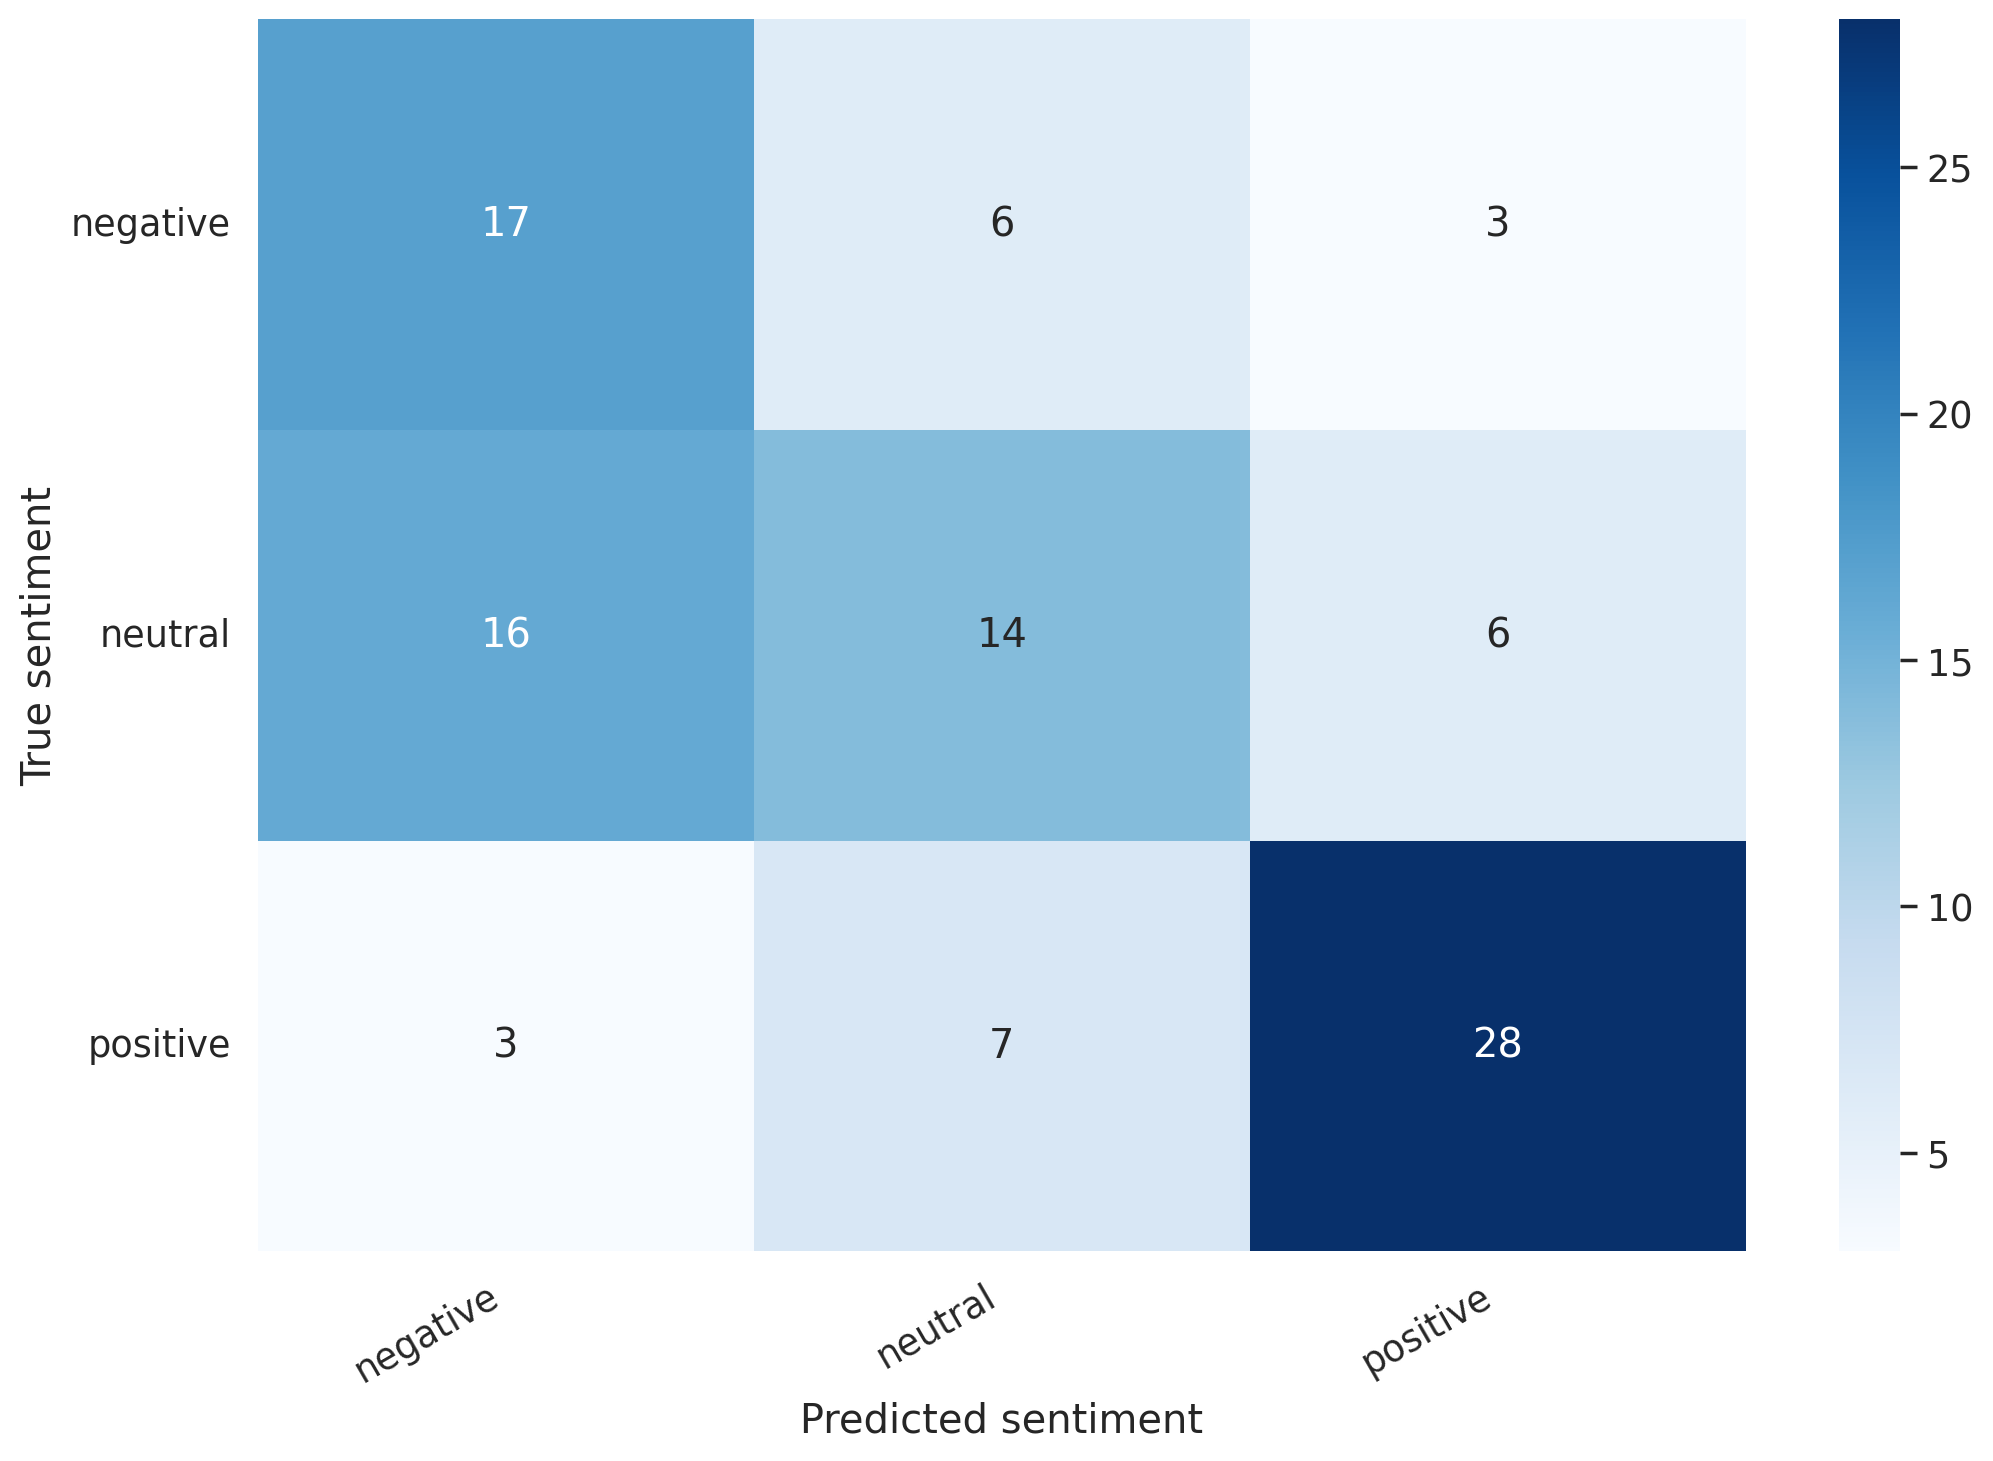

In [78]:
def show_confusion_matrix(confusion_matrix):
  hmap = sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
  hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
  hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
  plt.ylabel('True sentiment')
  plt.xlabel('Predicted sentiment');

cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
show_confusion_matrix(df_cm)

Здесь также можно видеть, что модели сложнее всего классифицировать нейтральные отзывы.

In [79]:
idx = 2

review_text = y_review_texts[idx]
true_sentiment = y_test[idx]
pred_df = pd.DataFrame({
  'class_names': class_names,
  'values': y_pred_probs[idx]
})

In [80]:
print("\n".join(wrap(review_text)))
print()
print(f'True sentiment: {class_names[true_sentiment]}')

I used to use Habitica, and I must say this is a great step up. I'd
like to see more social features, such as sharing tasks - only one
person has to perform said task for it to be checked off, but only
giving that person the experience and gold. Otherwise, the price for
subscription is too steep, thus resulting in a sub-perfect score. I
could easily justify $0.99/month or eternal subscription for $15. If
that price could be met, as well as fine tuning, this would be easily
worth 5 stars.

True sentiment: neutral


## Предсказание на произвольных текстах

Теперь нам осталось научиться использовать нашу модель для предсказания тональности любого текста.

In [81]:
review_text = "I love completing my todos! Best app ever!!!"

Для использования нашей модели нам следует токенизировать текст соответствующим образом.

In [82]:
encoded_review = tokenizer(
  review_text,
  max_length=MAX_LEN,
  add_special_tokens=True,
  return_token_type_ids=False,
  padding="max_length",
  return_attention_mask=True,
  return_tensors='pt',
)

Теперь получим предсказания нашей модели.

In [83]:
input_ids = encoded_review['input_ids'].to(device)
attention_mask = encoded_review['attention_mask'].to(device)

output = model(input_ids, attention_mask)
_, prediction = torch.max(output, dim=1)

print(f'Review text: {review_text}')
print(f'Sentiment  : {class_names[prediction]}')

Review text: I love completing my todos! Best app ever!!!
Sentiment  : positive


## Как изменились эмбеддинги?

Посмотрим на эмбеддинги расмотренных ранее слов subscription и premium после дообучения модели BERT.


In [84]:
sample_txt = df.loc[16]['content']
encoding = tokenizer(
  sample_txt,
  max_length=32,
  add_special_tokens=True, # Добавить '[CLS]' и '[SEP]'
  return_token_type_ids=False,
  padding="max_length",
  return_attention_mask=True,
  return_tensors='pt',  # Вернуть тензор PyTorch
)
encoding = encoding.to(device)
last_hidden_state = model.bert(
  input_ids=encoding['input_ids'],
  attention_mask=encoding['attention_mask']
)["last_hidden_state"]
idx0 = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0]).index('subscription')
emb0 = last_hidden_state[0, idx0]

In [85]:
sample_txt = df.loc[338]['content']
encoding = tokenizer(
  sample_txt,
  max_length=32,
  add_special_tokens=True, # Добавить '[CLS]' и '[SEP]'
  return_token_type_ids=False,
  padding="max_length",
  return_attention_mask=True,
  return_tensors='pt',  # Вернуть тензор PyTorch
)
encoding = encoding.to(device)
last_hidden_state = model.bert(
  input_ids=encoding['input_ids'],
  attention_mask=encoding['attention_mask']
)["last_hidden_state"]
idx1 = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0]).index('premium')
emb1 = last_hidden_state[0, idx1]

In [86]:
cosine_similarity([
    emb0.detach().cpu().numpy(),
    emb1.detach().cpu().numpy()])

array([[1.0000002, 0.5911791],
       [0.5911791, 0.9999999]], dtype=float32)

Можно увидеть, что в результате дообучения слова стали ближе друг к другу.

## Используем инструменты HuggingFace для классификации

Библиотека HuggingFace предоставляет инструменты, которые упрощают обучение и оценку моделей, выложенных в репозиторий библиотеки. Рассмотрим эти инструменты на примере задачи анализа тональности. Будем обучать и оценивать модели на датасете imdb, состоящем из отзывов пользователей о фильмах.

Оригинал: https://huggingface.co/transformers/custom_datasets.html#sequence-classification-with-imdb-reviews

Для загрузки датасета воспользуемся библиотекой datasets, реализованной HuggingFace. Данная библиотека предоставляет возможность быстро и удобно скачивать различные бенчмарки: https://huggingface.co/datasets

In [ ]:
!pip install datasets

In [88]:
from datasets import load_dataset

imdb_dataset = load_dataset('imdb')

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [89]:
imdb_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [90]:
imdb_dataset["train"]["text"][:10]

['I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, e

In [91]:
imdb_dataset["train"]["label"][:10]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Сократим количество примеров, чтобы процесс обучения был быстрее.

In [92]:
train_texts = imdb_dataset["train"]["text"][:2000]
train_labels = imdb_dataset["train"]["label"][:2000]
test_texts = imdb_dataset["test"]["text"][:1000]
test_labels = imdb_dataset["test"]["label"][:1000]

Выделим часть обучающих данных для оценки:

In [93]:
from sklearn.model_selection import train_test_split
train_texts, val_texts, train_labels, val_labels = train_test_split(train_texts, train_labels, test_size=.2)

Токенизируем данные

In [94]:
from transformers import DistilBertTokenizerFast
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

In [95]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)
test_encodings = tokenizer(test_texts, truncation=True, padding=True)

Создадим класс Dataset, который на каждой итерации будет возвращать токенизированный отзыв и класс:

In [96]:
class IMDbDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = IMDbDataset(train_encodings, train_labels)
val_dataset = IMDbDataset(val_encodings, val_labels)
test_dataset = IMDbDataset(test_encodings, test_labels)

Опишем функцию для подсчета метрик, которые хотим увидеть при оценке модели (по умолчанию будет вычисляться только loss):

In [97]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

Зададим параметры обучения с помощью TrainingArguments:

In [102]:
from transformers import DistilBertForSequenceClassification, Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',          # output directory
    num_train_epochs=2,              # total number of training epochs
    per_device_train_batch_size=4,  # batch size per device during training
    per_device_eval_batch_size=8,   # batch size for evaluation
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay
    logging_dir='./logs',            # directory for storing logs
    logging_steps=10,
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Инициализируем модель и запустим fine-tune с помощью модуля Trainer. В данном модуле будет автоматически происходить итерация по эпохам, батчам, рассчет функции потерь и градиентов, ничего этого больше руками прописывать не нужно!

In [103]:
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased")

trainer = Trainer(
    model=model,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=val_dataset,            # evaluation dataset
    compute_metrics = compute_metrics    # metrics to evaluate
)

trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
10,0.700438
20,0.664294
30,0.602197
40,0.530798
50,0.415691
60,0.226857
70,0.104565
80,0.041988
90,0.021037
100,0.012132


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=800, training_loss=0.04206878757040613, metrics={'train_runtime': 270.6273, 'train_samples_per_second': 11.824, 'train_steps_per_second': 2.956, 'total_flos': 423895675699200.0, 'train_loss': 0.04206878757040613, 'epoch': 2.0})

In [109]:
from transformers.utils.notebook import NotebookProgressCallback

trainer.remove_callback(NotebookProgressCallback)

In [110]:
trainer.evaluate()

{'eval_loss': 1.0293965715391096e-05,
 'eval_accuracy': 1.0,
 'eval_f1': 0.0,
 'eval_precision': 0.0,
 'eval_recall': 0.0,
 'eval_runtime': 9.3293,
 'eval_samples_per_second': 42.876,
 'eval_steps_per_second': 5.359,
 'epoch': 2.0}

Оценим модель на тестовых данных

In [111]:
trainer.evaluate(eval_dataset=test_dataset, metric_key_prefix="test")

{'test_loss': 1.0405483408248983e-05,
 'test_accuracy': 1.0,
 'test_f1': 0.0,
 'test_precision': 0.0,
 'test_recall': 0.0,
 'test_runtime': 23.0132,
 'test_samples_per_second': 43.453,
 'test_steps_per_second': 5.432,
 'epoch': 2.0}

## Практическое задание

1. Посмотрите на другие изменения эмбеддингов после дообучения модели BERT.
2. Попробуйте использовать другую предобученную модель BERT и сравните качество классификации. Модели Transformers: https://huggingface.co/transformers/pretrained_models.html
3. Попробуйте добавить аугментацию для восстановления баланса классов и обучить классификатор, сравните результаты с базовой версией модели.

Для аугментации можно попробовать использовать библиотеку [nlpaug](https://github.com/makcedward/nlpaug).

In [ ]:
!pip install nlpaug

In [136]:
from transformers import pipeline

fill_mask = pipeline("fill-mask", model="bert-base-uncased")

fill_mask("I love [MASK] programming")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'score': 0.15732425451278687,
  'token': 3274,
  'token_str': 'computer',
  'sequence': 'i love computer programming'},
 {'score': 0.15407195687294006,
  'token': 2115,
  'token_str': 'your',
  'sequence': 'i love your programming'},
 {'score': 0.050885360687971115,
  'token': 2189,
  'token_str': 'music',
  'sequence': 'i love music programming'},
 {'score': 0.04886357858777046,
  'token': 1996,
  'token_str': 'the',
  'sequence': 'i love the programming'},
 {'score': 0.04083341360092163,
  'token': 2023,
  'token_str': 'this',
  'sequence': 'i love this programming'}]

## Задание 1. Изменение эмбеддингов после дообучения

Посмотрим, как изменилось контекстное представление других слов (например, синонимов или антонимов).

In [120]:
from sklearn.metrics.pairwise import cosine_similarity
import torch

# Берем 4-й отзыв (индекс 3)
sample_txt = imdb_dataset["train"]["text"][3]

encoding = tokenizer(
  sample_txt,
  max_length=512,           
  truncation=True,          
  add_special_tokens=True,
  return_token_type_ids=False,
  padding="max_length",
  return_attention_mask=True,
  return_tensors='pt',
).to(device)

# Получаем скрытые состояния
with torch.no_grad():
    last_hidden_state = model.distilbert(
      input_ids=encoding['input_ids'],
      attention_mask=encoding['attention_mask']
    )["last_hidden_state"]

tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])

# Выводим токены, чтобы посмотреть, как токенизатор разбил текст
print("Список токенов:")
print(tokens)
print("-" * 30)

try:
    # Ищем слова с противоположной эмоциональной окраской
    idx1 = tokens.index('strong')
    idx2 = tokens.index('stupid')
    
    emb1 = last_hidden_state[0, idx1]
    emb2 = last_hidden_state[0, idx2]
    
    similarity = cosine_similarity([emb1.cpu().numpy(), emb2.cpu().numpy()])[0, 1]
    print(f"Косинусное сходство между 'strong' и 'stupid' после fine-tuning: {similarity:.4f}")
except ValueError as e:
    print("Ошибка:", e)

Список токенов:
['[CLS]', 'this', 'film', 'was', 'probably', 'inspired', 'by', 'god', '##ard', "'", 's', 'mas', '##cu', '##lin', ',', 'fe', '##mini', '##n', 'and', 'i', 'urge', 'you', 'to', 'see', 'that', 'film', 'instead', '.', '<', 'br', '/', '>', '<', 'br', '/', '>', 'the', 'film', 'has', 'two', 'strong', 'elements', 'and', 'those', 'are', ',', '(', '1', ')', 'the', 'realistic', 'acting', '(', '2', ')', 'the', 'impressive', ',', 'und', '##ese', '##r', '##ved', '##ly', 'good', ',', 'photo', '.', 'apart', 'from', 'that', ',', 'what', 'strikes', 'me', 'most', 'is', 'the', 'endless', 'stream', 'of', 'si', '##llin', '##ess', '.', 'lena', 'ny', '##man', 'has', 'to', 'be', 'most', 'annoying', 'actress', 'in', 'the', 'world', '.', 'she', 'acts', 'so', 'stupid', 'and', 'with', 'all', 'the', 'nu', '##dity', 'in', 'this', 'film', ',', '.', '.', '.', 'it', "'", 's', 'una', '##tt', '##ractive', '.', 'comparing', 'to', 'god', '##ard', "'", 's', 'film', ',', 'intellectual', '##ity', 'has', 'been',

## Задание 2. Использование другой предобученной модели

Используем классический bert-base-cased из библиотеки transformers для сравнения.

In [124]:
from transformers import BertTokenizerFast, BertForSequenceClassification, Trainer, TrainingArguments

# Используем TinyBERT (всего 2 слоя, весит около 17 МБ)
# Если памяти чуть больше, можно взять 'prajjwal1/bert-mini' (4 слоя)
model_name_2 = 'prajjwal1/bert-tiny'

print(f"Загрузка токенизатора и модели {model_name_2}...")
tokenizer_2 = BertTokenizerFast.from_pretrained(model_name_2)

# Токенизируем данные новым токенизатором
train_encodings_2 = tokenizer_2(train_texts, truncation=True, padding=True, max_length=512)
val_encodings_2 = tokenizer_2(val_texts, truncation=True, padding=True, max_length=512)
test_encodings_2 = tokenizer_2(test_texts, truncation=True, padding=True, max_length=512)

# Оборачиваем в наш класс IMDbDataset
train_dataset_2 = IMDbDataset(train_encodings_2, train_labels)
val_dataset_2 = IMDbDataset(val_encodings_2, val_labels)
test_dataset_2 = IMDbDataset(test_encodings_2, test_labels)

# Загружаем крошечную модель для классификации (2 класса)
model_2 = BertForSequenceClassification.from_pretrained(
    model_name_2, 
    num_labels=2, 
    use_safetensors=True # Добавьте этот флаг
).to(device)

# 1. Сначала создаем заново аргументы обучения
training_args_2 = TrainingArguments(
    output_dir='./results_bert_tiny',
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs_bert_tiny',
    report_to="none"
)

# 2. Создаем НОВЫЙ объект Trainer
trainer_2 = Trainer(
    model=model_2,
    args=training_args_2,
    train_dataset=train_dataset_2,
    eval_dataset=val_dataset_2,
    compute_metrics=compute_metrics
)

# 3. Запускаем обучение
print("Начинаем обучение Tiny BERT...")
trainer_2.train()

Загрузка токенизатора и модели prajjwal1/bert-tiny...


Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training o

Начинаем обучение Tiny BERT...


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=400, training_loss=0.15173615455627443, metrics={'train_runtime': 11.4245, 'train_samples_per_second': 280.1, 'train_steps_per_second': 35.012, 'total_flos': 4065558528000.0, 'train_loss': 0.15173615455627443, 'epoch': 2.0})

In [125]:
from transformers.utils.notebook import NotebookProgressCallback

trainer_2.remove_callback(NotebookProgressCallback)

In [130]:
print("\nОценка новой модели (Tiny BERT) на тестовой выборке:")
metrics_2 = trainer_2.evaluate(eval_dataset=test_dataset_2, metric_key_prefix="test")


Оценка новой модели (Tiny BERT) на тестовой выборке:


In [131]:
metrics_2

{'test_loss': 0.021441753953695297,
 'test_accuracy': 1.0,
 'test_f1': 0.0,
 'test_precision': 0.0,
 'test_recall': 0.0,
 'test_runtime': 0.9278,
 'test_samples_per_second': 1077.848,
 'test_steps_per_second': 67.904,
 'epoch': 2.0}

## Задание 3. Аугментация данных для балансировки классов
Вернемся к изначальному датасету (отзывы из Google Play — df_train), в котором мы наблюдали дисбаланс, и восстановим баланс миноритарных классов, создав новые примеры с помощью nlpaug.

Тут у меня закончилась видеопамять и пришлось делать всё заново...

In [1]:
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score
from tqdm import tqdm

# =========================
# 1. LOAD DATA
# =========================

df = pd.read_csv("reviews.csv")

# 5 классов: 0–4
df["sentiment"] = df["score"].astype(int) - 1
df = df[["content", "sentiment"]].dropna()

# =========================
# 2. BALANCE DATA (AUGMENTATION)
# =========================

device = 0 if torch.cuda.is_available() else -1

fill_mask = pipeline(
    "fill-mask",
    model="distilbert-base-uncased",
    device=device
)

class_counts = df.sentiment.value_counts()
max_size = class_counts.max()

aug_data = []

for label in sorted(df.sentiment.unique()):
    cls_df = df[df.sentiment == label]
    n_needed = max_size - len(cls_df)

    print(f"Class {label}: +{n_needed}")

    for _ in tqdm(range(n_needed)):

        text = cls_df.sample(1).content.values[0]
        words = text.split()

        if len(words) < 6:
            continue

        idx = len(words) // 2
        words[idx] = "[MASK]"

        try:
            out = fill_mask(" ".join(words[:128]))[0]["sequence"]

            aug_data.append({
                "content": out,
                "sentiment": label
            })

        except:
            continue


df_balanced = pd.concat([
    df,
    pd.DataFrame(aug_data)
], ignore_index=True)

# =========================
# 3. TRAIN / VAL SPLIT
# =========================

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_balanced["content"],
    df_balanced["sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=df_balanced["sentiment"]
)

# =========================
# 4. TOKENIZER + MODEL
# =========================

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# =========================
# 5. DATASET
# =========================

class SentimentDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = list(texts)
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=128,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = SentimentDataset(train_texts, train_labels)
val_dataset = SentimentDataset(val_texts, val_labels)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

# =========================
# 6. OPTIMIZER
# =========================

optimizer = AdamW(model.parameters(), lr=2e-5)

# =========================
# 7. TRAIN LOOP
# =========================

epochs = 3

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):

        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"]
        )

        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

    print(f"\nEpoch {epoch+1} loss: {total_loss/len(train_loader):.4f}")

# =========================
# 8. EVALUATION
# =========================

model.eval()

all_preds = []
all_labels_list = []

with torch.no_grad():
    for batch in val_loader:

        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels_list.extend(batch["labels"].cpu().numpy())

print("\n=== RESULTS ===")
print("Accuracy:", accuracy_score(all_labels_list, all_preds))
print("F1 (weighted):", f1_score(all_labels_list, all_preds, average="weighted"))

print("\nClassification report:\n")
print(classification_report(all_labels_list, all_preds))

# =========================
# 9. QUICK TEST
# =========================

def predict(text):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    return torch.argmax(outputs.logits, dim=1).item()

print("\nTESTS:")
print(predict("This product is amazing"))
print(predict("Worst experience ever"))
print(predict("It is okay, nothing special"))

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Class 0: +2476


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2476/2476 [00:31<00:00, 77.72it/s]


Class 1: +2580


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2580/2580 [00:32<00:00, 78.59it/s]


...


Epoch 1 loss: 1.0498


Epoch 2: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2402/2402 [06:31<00:00,  6.14it/s]



Epoch 2 loss: 0.6266


Epoch 3: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2402/2402 [06:30<00:00,  6.15it/s]



Epoch 3 loss: 0.3994

=== RESULTS ===
Accuracy: 0.8255620316402997
F1 (weighted): 0.8253431920583456

Classification report:

              precision    recall  f1-score   support

           0       0.85      0.90      0.88       957
           1       0.88      0.80      0.83       966
           2       0.77      0.77      0.77      1009
           3       0.80      0.81      0.80       953
           4       0.84      0.86      0.85       919

    accuracy                           0.83      4804
   macro avg       0.83      0.83      0.83      4804
weighted avg       0.83      0.83      0.83      4804


TESTS:
4
0
2
